# Bakery holdout 30d review (2026-05-02..2026-05-31)

Сравнение прогноза с фактом по пекарням за последние 30 дней train-выборки.

**Источник**: `reports/holdout_30d_bakery_compare.csv` — собран скриптом `scripts/build_holdout_30d_compare.py` из двух holdout-артефактов (base и uplifted модели), которые получены при weather-ретрейне 2026-06-03.

**Что считается "прогнозом"**: предсказание модели на test-фолде, который она НЕ видела при обучении (train_end = 2026-05-01). Это честная оценка качества модели; это НЕ то же самое, что прод-прогноз, который катит каждый день на горизонт +14.

**Не входит**: SKU-уровень. Holdout-артефакты только bakery-day. Для SKU нужен отдельный прогон с применением uplift-профиля.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CSV = REPO_ROOT / "reports" / "holdout_30d_bakery_compare.csv"
CHARTS_DIR = REPO_ROOT / "reports" / "holdout_30d_bakery_charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_CSV, parse_dates=["date"])
print(f"rows:      {len(df)}")
print(f"bakeries:  {df['bakery_id'].nunique()}")
print(f"cities:    {df['city'].nunique()}")
print(f"date range:{df['date'].min().date()} .. {df['date'].max().date()}")
df.head()

rows:      5474
bakeries:  187
cities:    9
date range:2026-05-02 .. 2026-05-31


,date,bakery_id,bakery_name,city,fact_base,forecast_base,fact_uplifted,forecast_uplifted,err_base,err_uplifted,abs_err_base,abs_err_uplifted
0,2026-05-02,1,Столичная 37А Зеленодольск,Зеленодольск,764.0,711.060067,958.774433,900.061278,-52.939933,-58.713155,52.939933,58.713155
1,2026-05-03,1,Столичная 37А Зеленодольск,Зеленодольск,689.5,676.712432,896.421246,857.978339,-12.787568,-38.442907,12.787568,38.442907
2,2026-05-04,1,Столичная 37А Зеленодольск,Зеленодольск,811.5,809.525415,999.214010,1042.377540,-1.974585,43.163529,1.974585,43.163529
3,2026-05-05,1,Столичная 37А Зеленодольск,Зеленодольск,850.5,804.675718,1043.652573,990.886227,-45.824282,-52.766346,45.824282,52.766346
4,2026-05-06,1,Столичная 37А Зеленодольск,Зеленодольск,727.0,843.676407,866.539097,1076.564640,116.676407,210.025544,116.676407,210.025544


## 1. Aggregate-метрики (sanity vs summary.json)

In [2]:
def agg_metrics(d, track):
    fact = d[f"fact_{track}"]
    fc = d[f"forecast_{track}"]
    err = fc - fact
    return {
        "MAE":   err.abs().mean(),
        "WMAPE": err.abs().sum() / fact.sum() * 100,
        "bias":  err.mean(),
        "sum_fact":     fact.sum(),
        "sum_forecast": fc.sum(),
    }

for track in ("base", "uplifted"):
    m = agg_metrics(df, track)
    print(f"--- {track} ---")
    for k, v in m.items():
        print(f"  {k:<13} {v:>14.4f}")

--- base ---
  MAE                  97.1842
  WMAPE                10.2906
  bias                -21.2703
  sum_fact        5169635.7210
  sum_forecast    5053202.1953
--- uplifted ---
  MAE                 137.3487
  WMAPE                12.0341
  bias                -26.7877
  sum_fact        6247636.0727
  sum_forecast    6101000.0336


## 2. Структура ошибки по дням окна

WMAPE по каждому дню — видны ли выбросы (праздники, погодные дни).

C:\Users\dns\AppData\Local\Temp\ipykernel_33648\2244312371.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_day = df.groupby("date").apply(


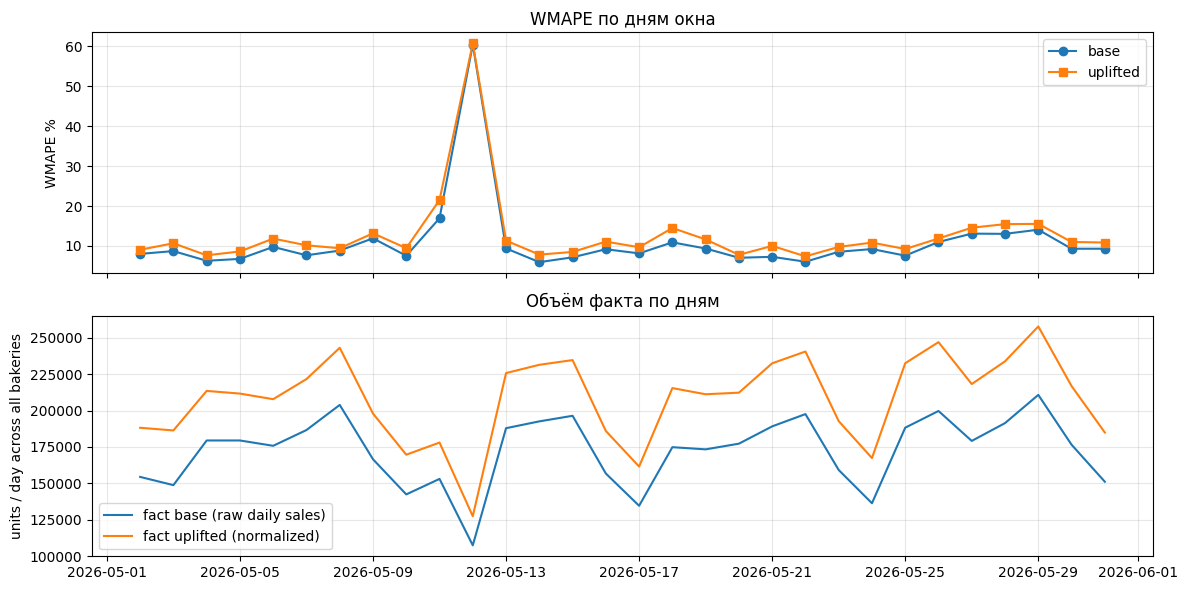

,date,wmape_base,wmape_uplifted,fact_base,fact_uplifted
0,2026-05-02,8.005017,9.040130,154375.494,188151.507060
1,2026-05-03,8.700408,10.663435,148717.352,186317.427367
2,2026-05-04,6.275922,7.650793,179418.507,213497.499654
3,2026-05-05,6.750863,8.608891,179420.969,211655.109803
4,2026-05-06,9.750404,11.836855,175761.107,207801.072614
5,2026-05-07,7.652074,10.155846,186593.521,221634.203022
6,2026-05-08,8.834458,9.415066,203859.250,243129.276892
7,2026-05-09,11.905458,13.164678,166520.105,197928.625350
8,2026-05-10,7.536399,9.439737,142353.409,169648.086618
9,2026-05-11,16.932785,21.503847,153008.207,177995.552352


In [3]:
by_day = df.groupby("date").apply(
    lambda g: pd.Series({
        "wmape_base":     g["abs_err_base"].sum() / g["fact_base"].sum() * 100,
        "wmape_uplifted": g["abs_err_uplifted"].sum() / g["fact_uplifted"].sum() * 100,
        "fact_base":      g["fact_base"].sum(),
        "fact_uplifted":  g["fact_uplifted"].sum(),
    })
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(by_day["date"], by_day["wmape_base"],     marker="o", label="base")
ax1.plot(by_day["date"], by_day["wmape_uplifted"], marker="s", label="uplifted")
ax1.set_ylabel("WMAPE %")
ax1.set_title("WMAPE по дням окна")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(by_day["date"], by_day["fact_base"],     label="fact base (raw daily sales)")
ax2.plot(by_day["date"], by_day["fact_uplifted"], label="fact uplifted (normalized)")
ax2.set_ylabel("units / day across all bakeries")
ax2.set_title("Объём факта по дням")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
by_day

## 3. По городам

In [4]:
by_city = df.groupby("city").apply(
    lambda g: pd.Series({
        "bakeries":       g["bakery_id"].nunique(),
        "rows":           len(g),
        "mae_base":       g["abs_err_base"].mean(),
        "wmape_base":     g["abs_err_base"].sum() / g["fact_base"].sum() * 100,
        "bias_base":      g["err_base"].mean(),
        "mae_uplifted":   g["abs_err_uplifted"].mean(),
        "wmape_uplifted": g["abs_err_uplifted"].sum() / g["fact_uplifted"].sum() * 100,
        "bias_uplifted":  g["err_uplifted"].mean(),
    })
).sort_values("wmape_base", ascending=False)
by_city.round(2)

C:\Users\dns\AppData\Local\Temp\ipykernel_33648\3486234341.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_city = df.groupby("city").apply(


,bakeries,rows,mae_base,wmape_base,bias_base,mae_uplifted,wmape_uplifted,bias_uplifted
city,,,,,,,,
unknown,1.0,8.0,147.14,31.91,147.14,238.32,51.68,238.32
Чебоксары,20.0,572.0,86.14,11.58,-19.86,122.89,13.94,-16.11
Курск,12.0,330.0,65.09,11.23,0.34,97.93,13.72,10.82
Заинск,4.0,120.0,92.44,11.04,-2.32,125.98,12.78,-0.38
Нижнекамск,13.0,390.0,91.65,10.59,-18.56,123.81,12.01,-27.72
Казань,113.0,3334.0,105.05,10.25,-25.23,146.51,11.89,-33.39
Москва,1.0,30.0,83.61,9.95,-27.40,132.53,12.51,-33.31
Набережные Челны,13.0,390.0,86.28,9.21,-23.84,128.73,10.96,-33.98
Зеленодольск,10.0,300.0,89.42,8.79,-15.34,137.64,10.69,-21.56


## 4. По пекарням: рейтинг ошибки

In [5]:
by_bakery = df.groupby(["bakery_id", "bakery_name", "city"]).apply(
    lambda g: pd.Series({
        "days":           len(g),
        "mean_fact_base": g["fact_base"].mean(),
        "mae_base":       g["abs_err_base"].mean(),
        "bias_base":      g["err_base"].mean(),
        "wmape_base":     g["abs_err_base"].sum() / g["fact_base"].sum() * 100,
        "mae_uplifted":   g["abs_err_uplifted"].mean(),
        "bias_uplifted":  g["err_uplifted"].mean(),
        "wmape_uplifted": g["abs_err_uplifted"].sum() / g["fact_uplifted"].sum() * 100,
    })
).reset_index()

print("Худшие 15 по WMAPE base:")
display(by_bakery.sort_values("wmape_base", ascending=False).head(15).round(2))
print("\nТоп-15 over-forecast (модель завышает, bias_base < 0):")
display(by_bakery.sort_values("bias_base").head(15).round(2))
print("\nТоп-15 under-forecast (модель занижает, bias_base > 0):")
display(by_bakery.sort_values("bias_base", ascending=False).head(15).round(2))

Худшие 15 по WMAPE base:


C:\Users\dns\AppData\Local\Temp\ipykernel_33648\2964977645.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_bakery = df.groupby(["bakery_id", "bakery_name", "city"]).apply(


,bakery_id,bakery_name,city,days,mean_fact_base,mae_base,bias_base,wmape_base,mae_uplifted,bias_uplifted,wmape_uplifted
167,250,Вокзальная 1 Курск,Курск,2.0,619.00,560.31,-350.79,90.52,537.86,-220.85,86.89
184,270,Восточная 1к1 Новочебоксарск,unknown,8.0,461.12,147.14,147.14,31.91,238.32,238.32,51.68
186,273,Проспект Универсиады 10 Казань,Казань,3.0,1123.21,337.18,-282.19,30.02,314.72,-204.28,28.02
185,272,Четаева 4 Казань,Казань,6.0,998.14,291.45,-196.59,29.20,267.03,-117.12,26.75
183,268,Новогородская 40 Чебоксары,Чебоксары,10.0,625.91,164.38,9.93,26.26,185.70,85.39,28.44
182,267,Шевченко 3 Зеленодольск,Казань,25.0,633.42,142.07,25.55,22.43,186.22,47.38,24.83
181,266,Мусина 61В Казань,Казань,30.0,386.10,71.73,56.62,18.58,134.56,123.15,29.88
71,86,Лемаева 2А Нижнекамск,Нижнекамск,30.0,990.22,175.70,-42.63,17.74,164.48,-40.29,16.60
74,90,Привокзальная 1Д Чебоксары,Чебоксары,30.0,552.40,92.04,-27.89,16.66,148.88,-45.13,21.10
165,246,Спиридона Михайлова 1 Чебоксары,Чебоксары,30.0,464.66,76.33,-18.12,16.43,116.86,-28.18,20.31



Топ-15 over-forecast (модель завышает, bias_base < 0):


,bakery_id,bakery_name,city,days,mean_fact_base,mae_base,bias_base,wmape_base,mae_uplifted,bias_uplifted,wmape_uplifted
167,250,Вокзальная 1 Курск,Курск,2.0,619.00,560.31,-350.79,90.52,537.86,-220.85,86.89
186,273,Проспект Универсиады 10 Казань,Казань,3.0,1123.21,337.18,-282.19,30.02,314.72,-204.28,28.02
185,272,Четаева 4 Казань,Казань,6.0,998.14,291.45,-196.59,29.20,267.03,-117.12,26.75
64,77,Гагарина 17Б Чебоксары,Чебоксары,30.0,1026.46,141.28,-100.68,13.76,141.72,-96.52,13.81
73,89,Парина 6 Казань,Казань,30.0,1899.83,203.96,-95.30,10.74,311.85,-183.58,13.06
147,218,Проспект Победы 147 Казань,Казань,30.0,829.38,108.31,-92.15,13.06,140.10,-116.08,13.05
44,50,Адоратского 31Б Казань,Казань,30.0,1367.10,151.36,-86.81,11.07,215.58,-111.22,12.44
123,169,Державина 9б Сокуры,Казань,30.0,1169.60,149.69,-85.68,12.80,233.74,-129.60,15.21
145,201,19 квартал 8/1 Казань Куюки,Казань,30.0,1172.65,142.12,-78.95,12.12,140.89,-66.72,12.01
84,105,Фучика 96 Казань,Казань,30.0,1633.44,157.54,-73.50,9.64,162.93,-78.74,9.93



Топ-15 under-forecast (модель занижает, bias_base > 0):


,bakery_id,bakery_name,city,days,mean_fact_base,mae_base,bias_base,wmape_base,mae_uplifted,bias_uplifted,wmape_uplifted
184,270,Восточная 1к1 Новочебоксарск,unknown,8.0,461.12,147.14,147.14,31.91,238.32,238.32,51.68
16,18,Хади Такташ 105 Казань,Казань,30.0,1411.20,146.73,57.55,10.40,146.73,59.06,10.40
181,266,Мусина 61В Казань,Казань,30.0,386.10,71.73,56.62,18.58,134.56,123.15,29.88
28,30,Баумана 29/11 Казань,Казань,30.0,1907.60,236.21,45.23,12.38,227.36,25.41,11.92
103,142,Баки Урманче 6 Казань,Казань,30.0,1712.09,155.06,44.45,9.06,234.16,13.01,10.87
177,262,Харьковская 3 Курск,Курск,30.0,973.07,76.07,36.52,7.82,117.98,56.70,9.92
40,45,Декабристов 8 Казань,Казань,30.0,1067.87,117.70,30.50,11.02,185.03,42.65,13.80
10,12,Восстания 117 Казань,Казань,30.0,1316.96,113.43,27.75,8.61,165.21,12.09,10.26
182,267,Шевченко 3 Зеленодольск,Казань,25.0,633.42,142.07,25.55,22.43,186.22,47.38,24.83
17,19,Хади Такташ 73 Казань,Казань,30.0,1223.66,97.92,25.04,8.00,150.65,23.22,9.87


## 5. Графики по пекарням

Один график на пекарню, 4 линии:
- `fact_base` — фактическое количество (сырые ежедневные продажи)
- `forecast_base` — что предсказала base-модель
- `fact_uplifted` — фактическое количество в uplifted-метрике (нормализованное)
- `forecast_uplifted` — что предсказала uplifted-модель

Чтобы не флудить ноутбук 187-ю графиками подряд, по умолчанию рисуем top-N худших по `wmape_base` (изменить `TOP_N` ниже).
Все 187 PNG сохраняются в `reports/holdout_30d_bakery_charts/` независимо от того, что показано в ноутбуке.

Показываю топ-20 худших пекарен по WMAPE base:


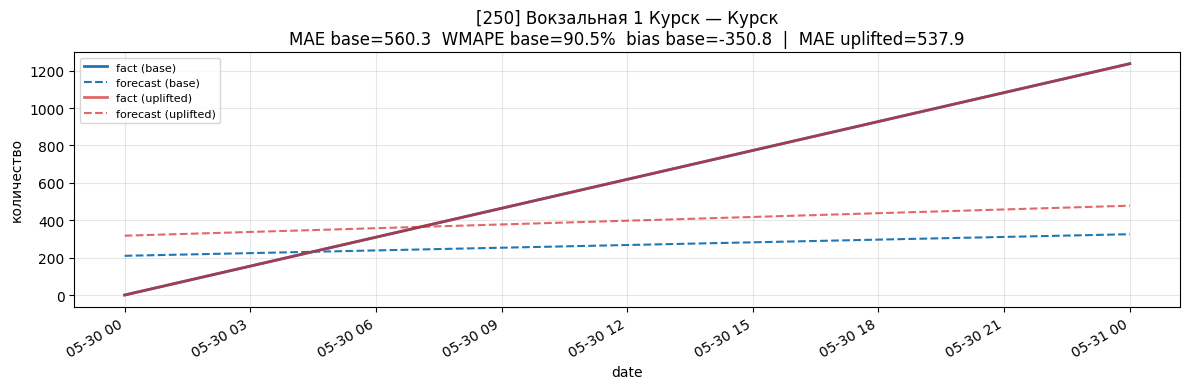

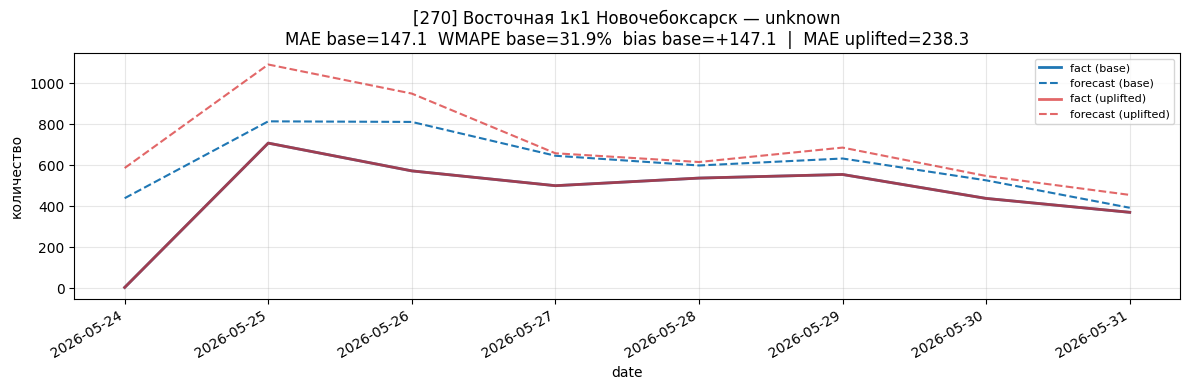

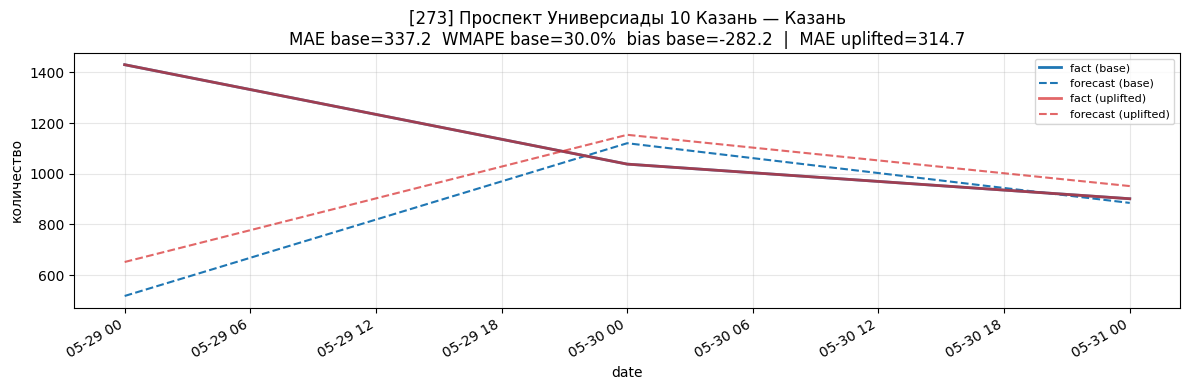

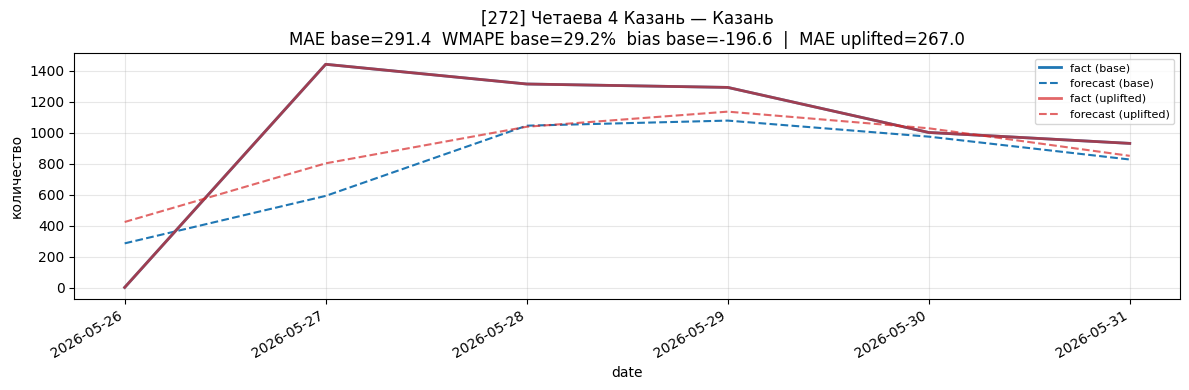

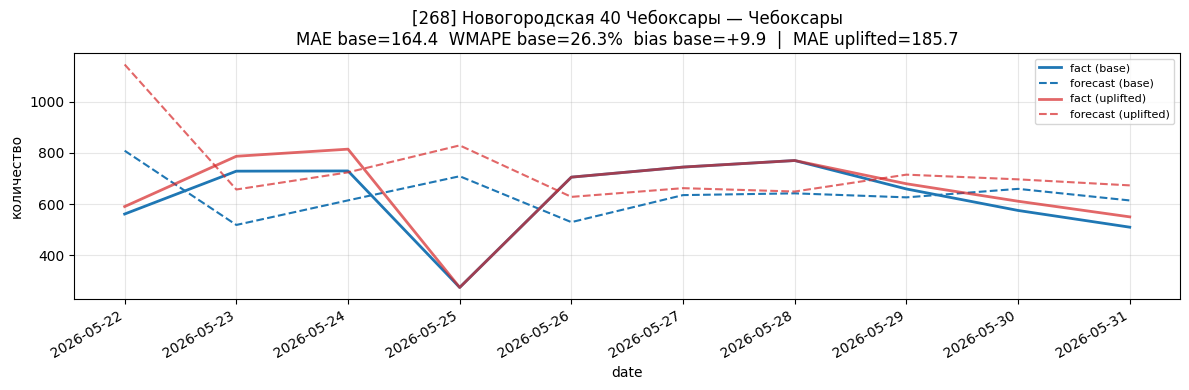

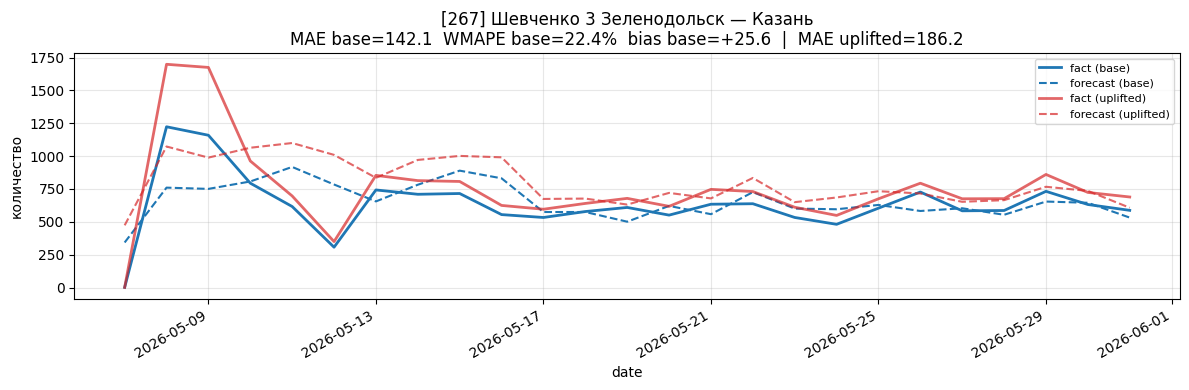

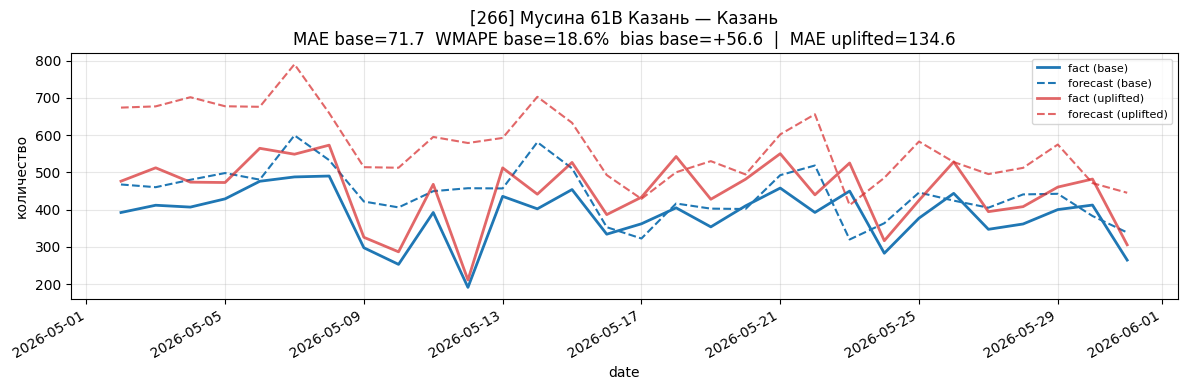

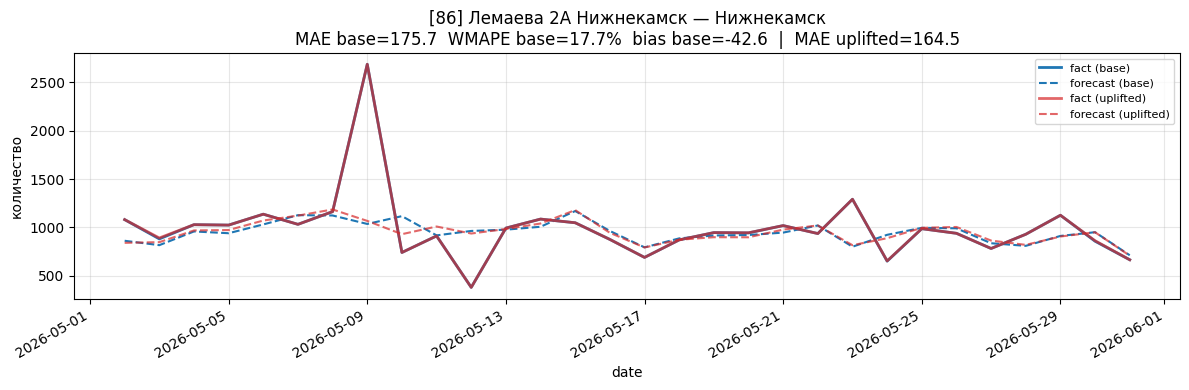

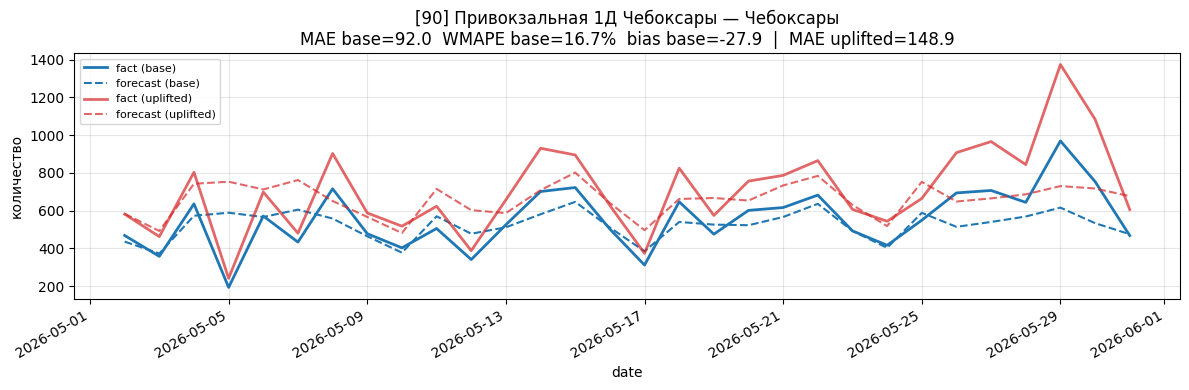

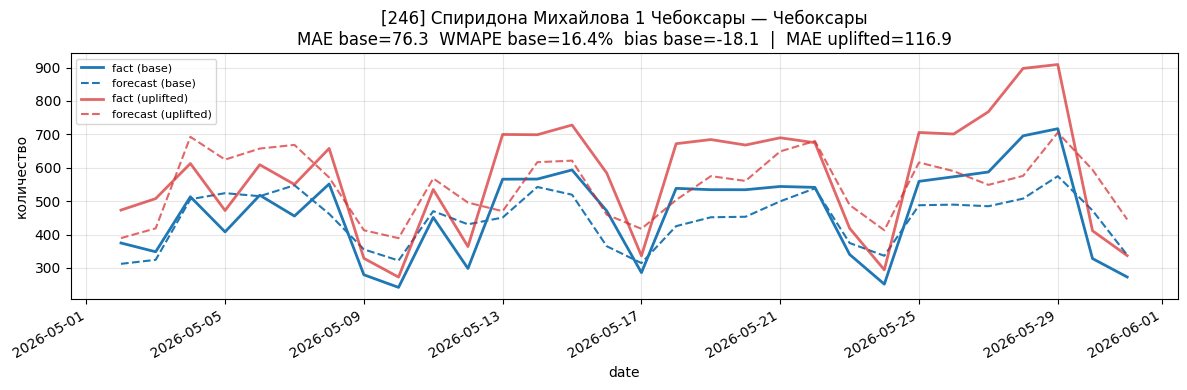

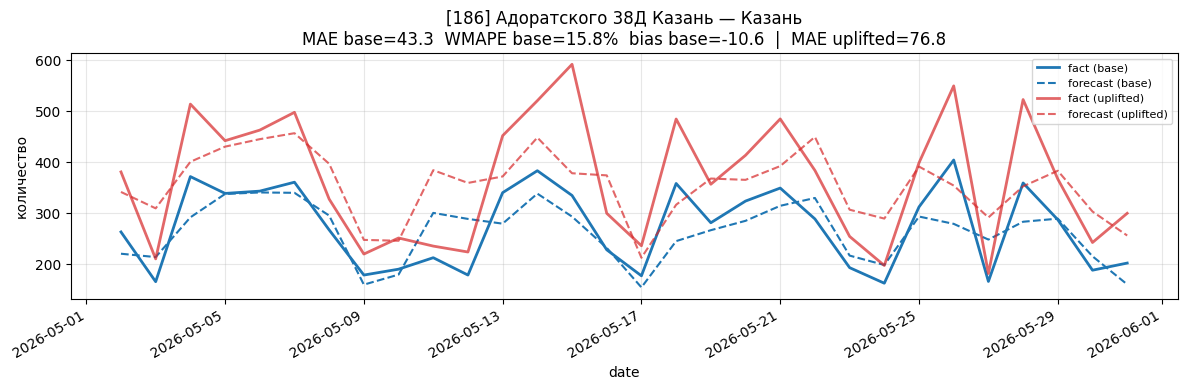

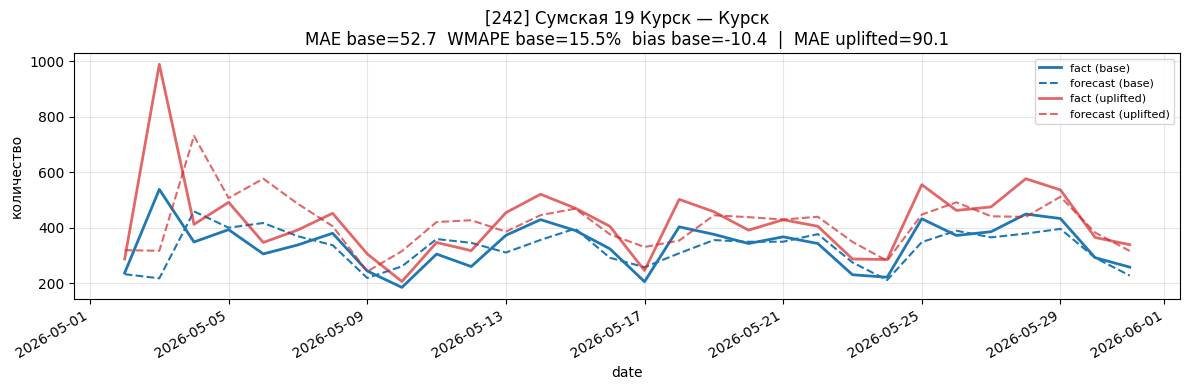

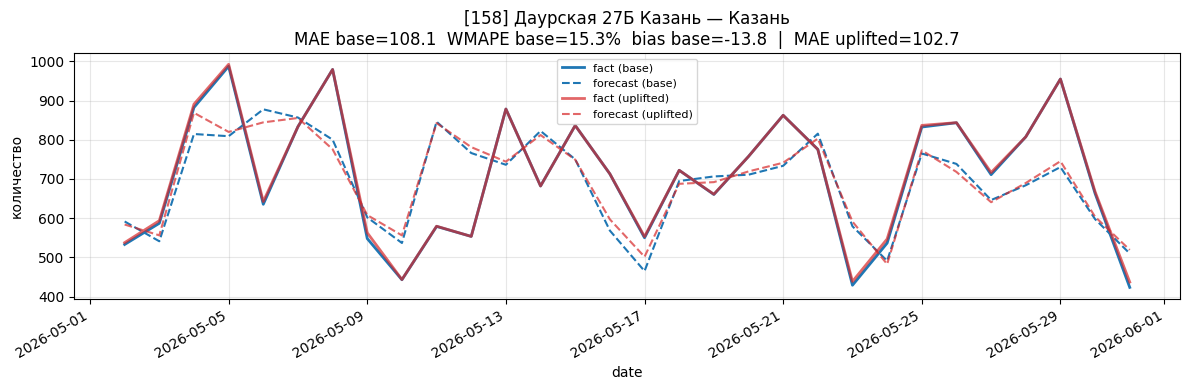

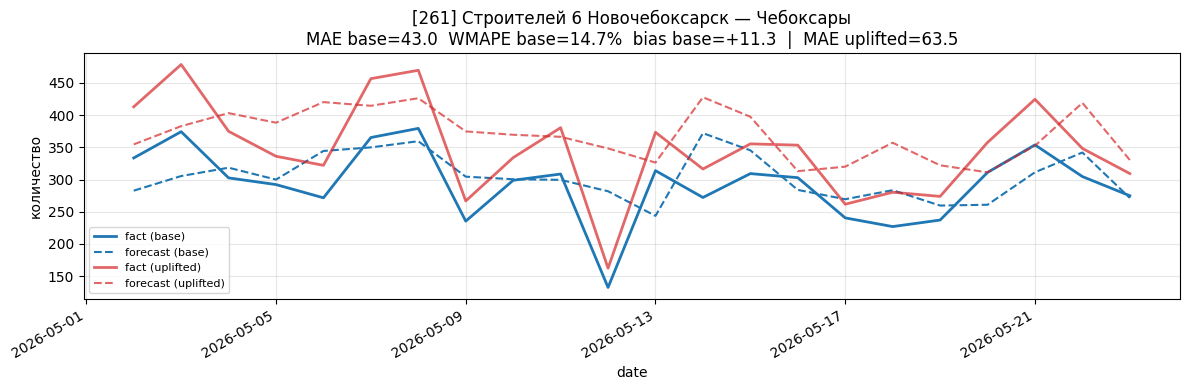

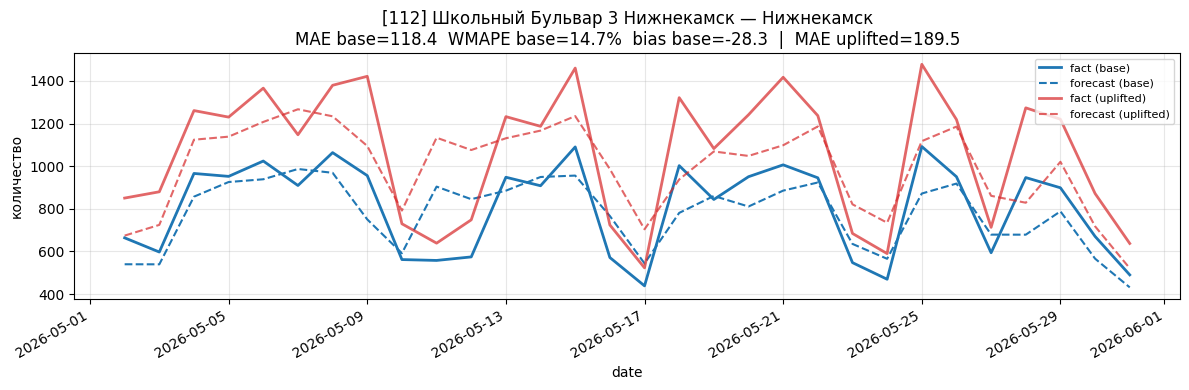

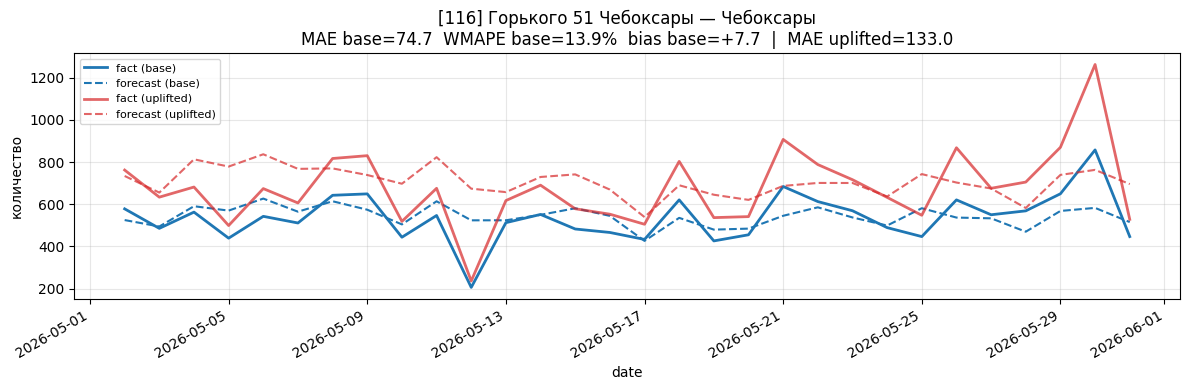

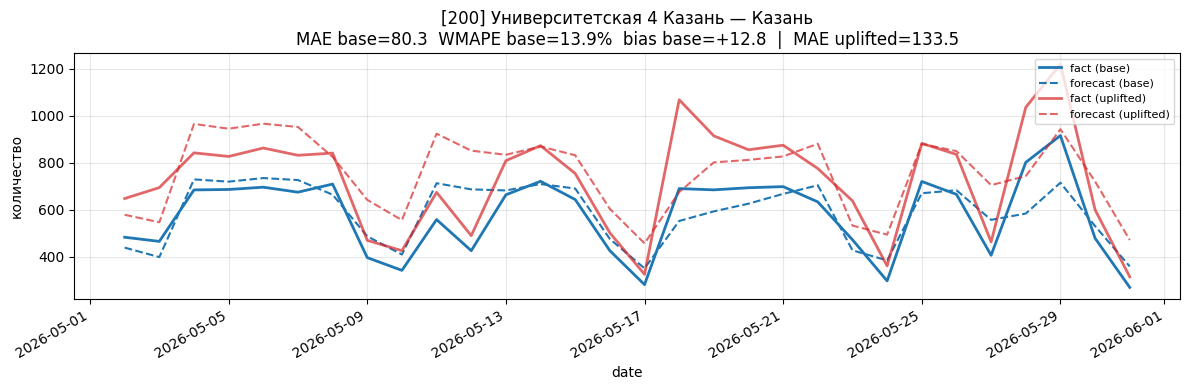

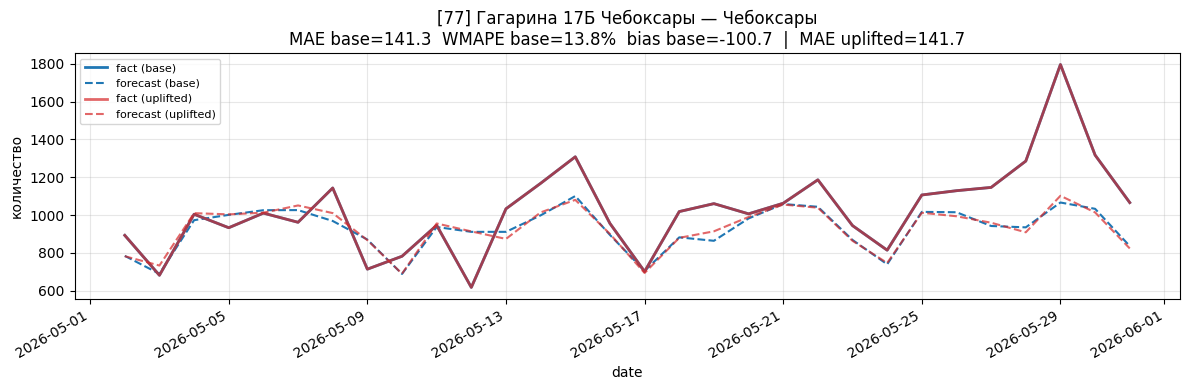

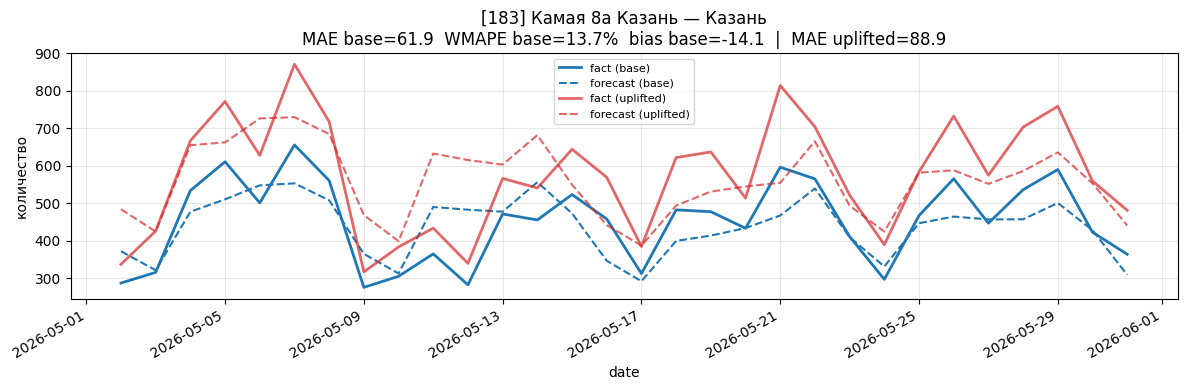

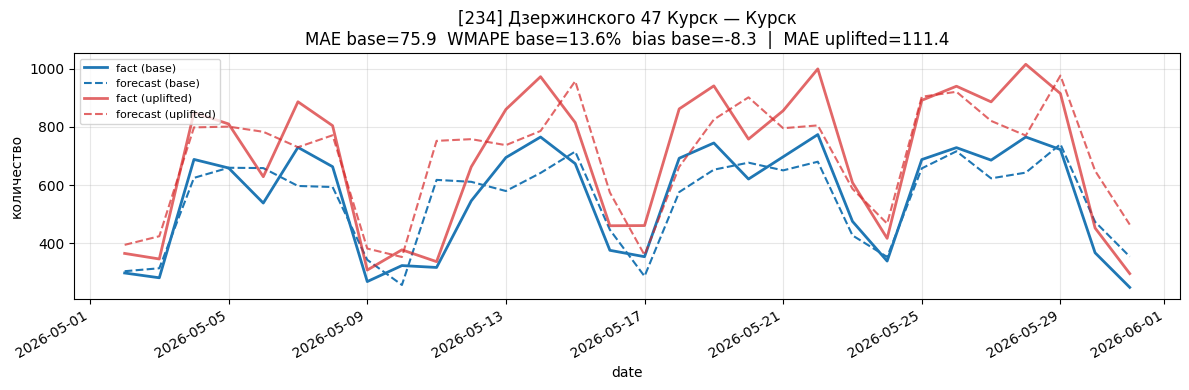


Досохраняю PNG для остальных 167 пекарен...
Готово. Все PNG лежат в: c:\Users\dns\Desktop\Projects\demand-forecasting-model\reports\holdout_30d_bakery_charts


In [6]:
TOP_N = 20              # сколько худших пекарен показать в ноутбуке
SAVE_ALL_PNGS = True    # сохранить PNG для ВСЕХ пекарен в reports/holdout_30d_bakery_charts/

def plot_bakery(bakery_id, *, save_only=False):
    g = df[df["bakery_id"] == bakery_id].sort_values("date")
    if g.empty:
        return
    name = g["bakery_name"].iloc[0]
    city = g["city"].iloc[0]
    mae_b = g["abs_err_base"].mean()
    mae_u = g["abs_err_uplifted"].mean()
    bias_b = g["err_base"].mean()
    wmape_b = g["abs_err_base"].sum() / g["fact_base"].sum() * 100

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(g["date"], g["fact_base"],         label="fact (base)",         color="#1f77b4", linewidth=2)
    ax.plot(g["date"], g["forecast_base"],     label="forecast (base)",     color="#1f77b4", linestyle="--")
    ax.plot(g["date"], g["fact_uplifted"],     label="fact (uplifted)",     color="#d62728", linewidth=2, alpha=0.7)
    ax.plot(g["date"], g["forecast_uplifted"], label="forecast (uplifted)", color="#d62728", linestyle="--", alpha=0.7)
    ax.set_title(f"[{bakery_id}] {name} — {city}\n"
                 f"MAE base={mae_b:.1f}  WMAPE base={wmape_b:.1f}%  bias base={bias_b:+.1f}  |  MAE uplifted={mae_u:.1f}")
    ax.set_xlabel("date"); ax.set_ylabel("количество")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    fig.tight_layout()
    out = CHARTS_DIR / f"bakery_{bakery_id:04d}.png"
    fig.savefig(out, dpi=120)
    if save_only:
        plt.close(fig)
    else:
        plt.show()

worst = by_bakery.sort_values("wmape_base", ascending=False).head(TOP_N)
print(f"Показываю топ-{TOP_N} худших пекарен по WMAPE base:")
for bid in worst["bakery_id"]:
    plot_bakery(int(bid))

if SAVE_ALL_PNGS:
    rest = [int(b) for b in by_bakery["bakery_id"] if int(b) not in set(worst["bakery_id"])]
    print(f"\nДосохраняю PNG для остальных {len(rest)} пекарен...")
    for bid in rest:
        plot_bakery(bid, save_only=True)
    print(f"Готово. Все PNG лежат в: {CHARTS_DIR}")

## 6. Посмотреть конкретную пекарню по id

Меняй `BAKERY_ID` и перезапускай ячейку.

In [10]:
df[df['bakery_name'] == 'Баки Урманче 6 Казань']

,date,bakery_id,bakery_name,city,fact_base,forecast_base,fact_uplifted,forecast_uplifted,err_base,err_uplifted,abs_err_base,abs_err_uplifted
3090,2026-05-02,142,Баки Урманче 6 Казань,Казань,1591.761,1562.469397,2040.720579,2041.624573,-29.291603,0.903994,29.291603,0.903994
3091,2026-05-03,142,Баки Урманче 6 Казань,Казань,1441.872,1582.694885,1785.425756,1960.203786,140.822885,174.778030,140.822885,174.778030
3092,2026-05-04,142,Баки Урманче 6 Казань,Казань,1814.530,1852.045185,2229.827662,2322.688864,37.515185,92.861202,37.515185,92.861202
3093,2026-05-05,142,Баки Урманче 6 Казань,Казань,1742.983,1939.725387,2153.294643,2367.779449,196.742387,214.484807,196.742387,214.484807
3094,2026-05-06,142,Баки Урманче 6 Казань,Казань,1688.558,2002.406945,2034.146117,2418.759848,313.848945,384.613731,313.848945,384.613731
3095,2026-05-07,142,Баки Урманче 6 Казань,Казань,1828.249,1976.807235,2223.822282,2470.826209,148.558235,247.003927,148.558235,247.003927
3096,2026-05-08,142,Баки Урманче 6 Казань,Казань,1939.907,1985.185197,2292.162564,2321.652069,45.278197,29.489505,45.278197,29.489505
3097,2026-05-09,142,Баки Урманче 6 Казань,Казань,1517.352,1710.166778,1846.626456,1978.832595,192.814778,132.206140,192.814778,132.206140
3098,2026-05-10,142,Баки Урманче 6 Казань,Казань,1496.666,1501.745215,1827.885537,1769.740482,5.079215,-58.145055,5.079215,58.145055
3099,2026-05-11,142,Баки Урманче 6 Казань,Казань,1430.281,1776.357399,1714.788475,2169.927402,346.076399,455.138926,346.076399,455.138926


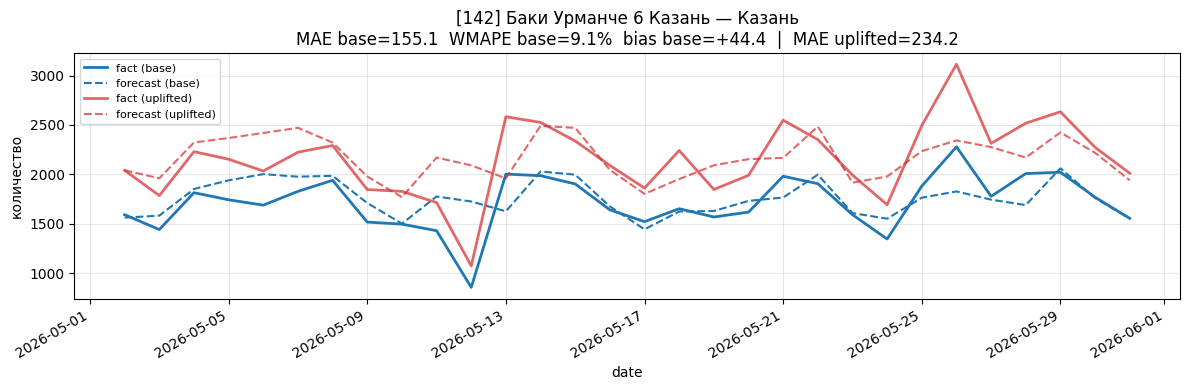

In [11]:
BAKERY_ID = 142  # пример из smoke-тестов (Энергетиков 3 Казань)
plot_bakery(BAKERY_ID)

## 7. Лучшие пекарни (для контраста)

Чтобы понять, как выглядит "хорошо предсказывается".

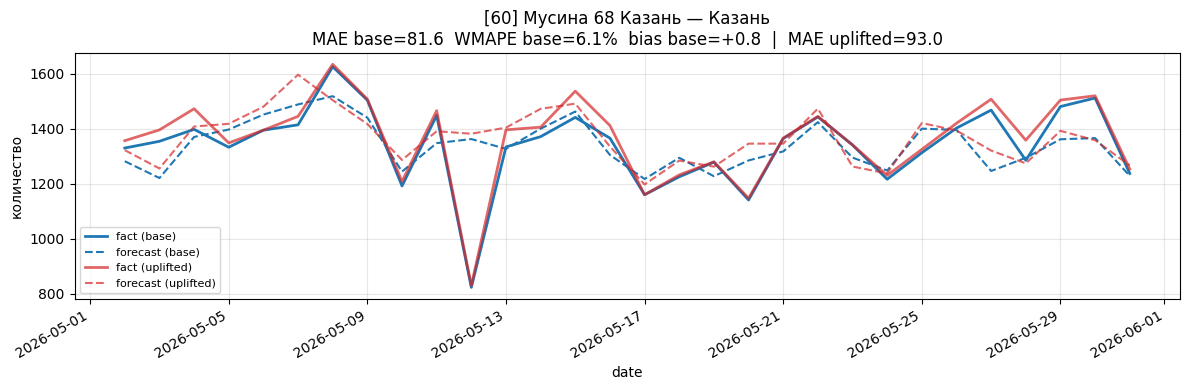

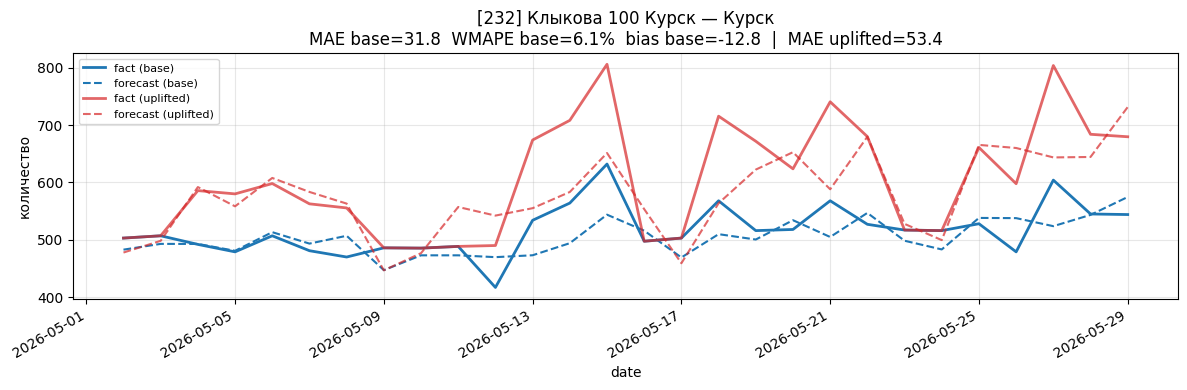

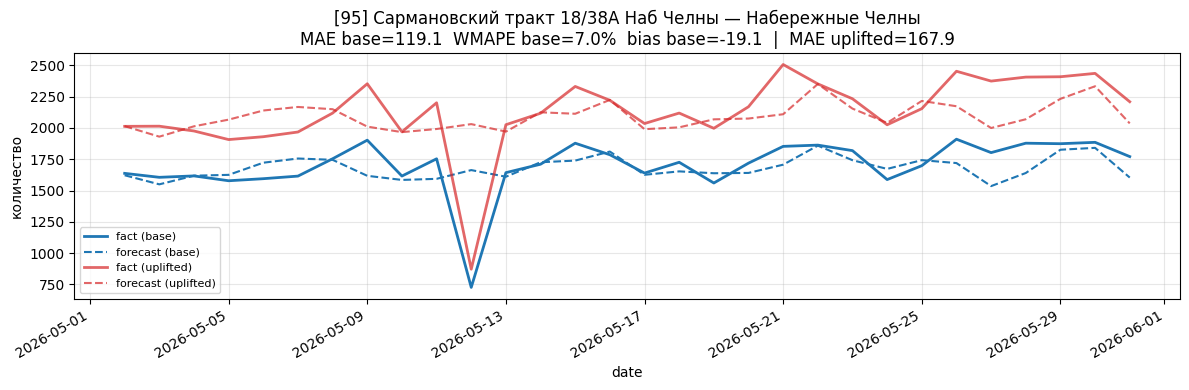

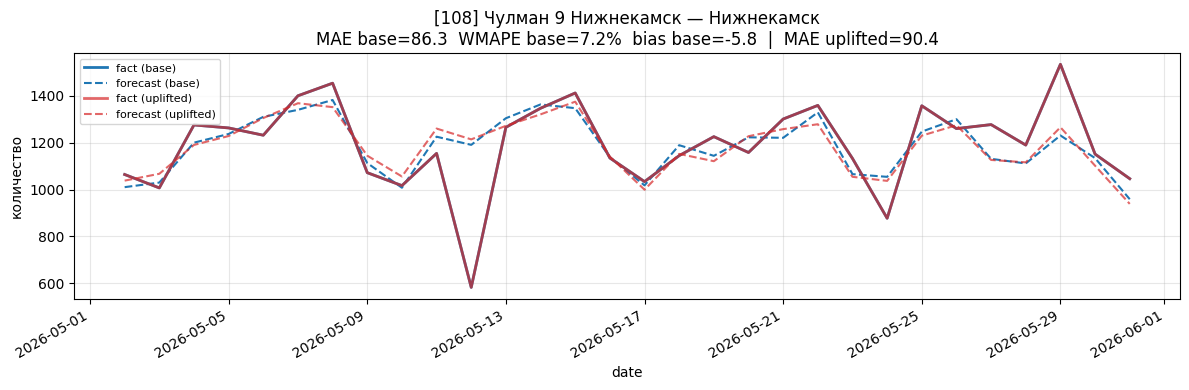

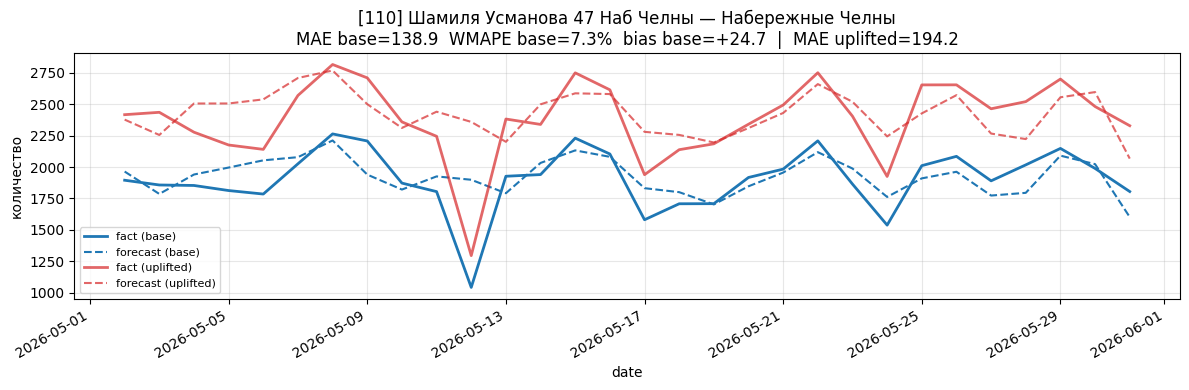

In [8]:
best = by_bakery.sort_values("wmape_base").head(5)
for bid in best["bakery_id"]:
    plot_bakery(int(bid))